# Лабораторная работа 6. DR + Кластеризация + Метрики качества


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (
    silhouette_score, calinski_harabasz_score, davies_bouldin_score,
    adjusted_rand_score, adjusted_mutual_info_score
)

import umap
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['figure.dpi'] = 100

print('ok')

ok


## 1. Загрузка и подготовка данных

In [2]:
# --- Iris ---
iris = load_iris()
X_iris = StandardScaler().fit_transform(iris.data)
y_iris = iris.target

print(f'Iris: форма={X_iris.shape}, классов={len(np.unique(y_iris))}')
print(f'Баланс: {np.bincount(y_iris)}')

Iris: форма=(150, 4), классов=3
Баланс: [50 50 50]


In [3]:
df = pd.read_csv('./Job_Placement_Data_Enhanced.csv')
from sklearn.preprocessing import OneHotEncoder

object_cols = [t for t in df.select_dtypes(include='object').columns.to_list() if t != 'status']
for col in object_cols:
    cats = np.unique(df[col].values)
    l_enc = OneHotEncoder().fit(cats.reshape(1, -1))
    encoded_names = l_enc.get_feature_names_out(cats)
    for cat, name in zip(cats, encoded_names):
        df[name] = (df[col] == cat).astype(int)


placed = df[df['status'] == 'Placed'].copy()
not_placed = df[df['status'] == 'Not Placed'].copy()
delta = len(placed) - len(not_placed)
df = pd.concat([df, not_placed.sample(n=delta, replace=True)])
target_classes = df.select_dtypes(include='number').columns.to_list()
feature_cols = [col for col in df.columns if col not in ['status', 'status_enc', *object_cols]]

le = LabelEncoder()
df['status_enc'] = le.fit_transform(df['status'])
label_names = {i: n for i, n in enumerate(le.classes_)}
X_raw = df[feature_cols].values
y = df['status_enc'].values
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)
X_sub = X
y_sub = y

## 2. Применение методов снижения размерности

In [5]:
def apply_dr_methods(X, seed=42):
    #Применяет PCA, t-SNE и UMAP к матрице X. Возвращает словарь 2Dвложений
    results = {}

    # PCA
    t0 = time.time()
    results['PCA'] = PCA(n_components=2, random_state=seed).fit_transform(X)
    print(f'PCA: {time.time()-t0:.2f}s')

    # t-SNE
    t0 = time.time()
    results['t-SNE'] = TSNE(n_components=2, perplexity=30, random_state=seed).fit_transform(X)
    print(f't-SNE: {time.time()-t0:.2f}s')

    # UMAP
    t0 = time.time()
    results['UMAP'] = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=seed).fit_transform(X)
    print(f'UMAP: {time.time()-t0:.2f}s')

    return results

print('=== Iris ===')
dr_iris = apply_dr_methods(X_iris)

print('\n=== Job Status ===')
dr_job = apply_dr_methods(X)

=== Iris ===
PCA: 0.00s
t-SNE: 0.53s
UMAP: 0.38s

=== Job Status ===
PCA: 0.00s
t-SNE: 0.79s
UMAP: 0.90s


PCA во всех случаях работал значительно быстрее остальных методов. 
t-SNE оказался быстрее UMAP на моем датасете, но медленнее на Iris.

## 3. Кластеризация на DR-вложениях

In [17]:
def cluster_and_score(X_2d, y_true, n_clusters, seed=42):
    # Параметры DBSCAN: подбираем автоматически
    from sklearn.neighbors import NearestNeighbors
    nbrs = NearestNeighbors(n_neighbors=5).fit(X_2d)
    dists, _ = nbrs.kneighbors(X_2d)
    eps = np.percentile(dists[:, -1], 90)  # 90-й перцентиль k-расстояний

    algorithms = {
        'KMeans': KMeans(n_clusters=n_clusters, random_state=seed, n_init=10),
        'Agglomerative': AgglomerativeClustering(n_clusters=n_clusters),
        'DBSCAN': DBSCAN(eps=eps, min_samples=5),
    }

    rows = []
    labels_dict = {}
    for name, algo in algorithms.items():
        labels = algo.fit_predict(X_2d)
        labels_dict[name] = labels

        # Проверка: нужно минимум 2 кластера для метрик
        n_found = len(np.unique(labels[labels != -1]))
        if n_found < 2:
            rows.append({'Алгоритм': name, 'Кластеров': n_found,
                         'Silhouette': np.nan, 'CH': np.nan, 'DB': np.nan,
                         'ARI': np.nan, 'AMI': np.nan})
            continue

        # Маска: исключаем шум DBSCAN
        mask = labels != -1
        X_m, y_m, l_m = X_2d[mask], y_true[mask], labels[mask]

        sil = silhouette_score(X_m, l_m)
        ch  = calinski_harabasz_score(X_m, l_m)
        db  = davies_bouldin_score(X_m, l_m)
        ari = adjusted_rand_score(y_m, l_m)
        ami = adjusted_mutual_info_score(y_m, l_m)

        rows.append({'Алгоритм': name, 'Кластеров': n_found,
                     'Silhouette': round(sil, 3), 'CH': round(ch, 1),
                     'DB': round(db, 3), 'ARI': round(ari, 3), 'AMI': round(ami, 3)})

    return pd.DataFrame(rows), labels_dict

print('Функция кластеризации определена.')

Функция кластеризации определена.


функция автоматически подбирает eps для DBSCAN через 90й перцентиль k-расстояний. Для DBSCAN точки с label=-1 (шум) исключаются из подсчёта метрик

## 4. Результаты на Iris

In [7]:
N_CLUSTERS_IRIS = 3
all_scores_iris = []
all_labels_iris = {}

for dr_name, X_2d in dr_iris.items():
    scores_df, labels_dict = cluster_and_score(X_2d, y_iris, N_CLUSTERS_IRIS)
    scores_df.insert(0, 'DR', dr_name)
    all_scores_iris.append(scores_df)
    all_labels_iris[dr_name] = labels_dict

results_iris = pd.concat(all_scores_iris, ignore_index=True)
print('=== Метрики кластеризации на Iris ===')
print(results_iris.to_string(index=False))

=== Метрики кластеризации на Iris ===
   DR      Алгоритм  Кластеров  Silhouette     CH    DB   ARI   AMI
  PCA        KMeans          3       0.509  293.9 0.710 0.620 0.655
  PCA Agglomerative          3       0.511  286.3 0.705 0.586 0.638
  PCA        DBSCAN          2       0.640  334.7 0.502 0.568 0.732
t-SNE        KMeans          3       0.651 2916.2 0.486 0.610 0.649
t-SNE Agglomerative          3       0.610 2338.1 0.466 0.654 0.746
t-SNE        DBSCAN          3       0.296 1253.0 0.886 0.567 0.706
 UMAP        KMeans          3       0.633 2363.5 0.522 0.631 0.663
 UMAP Agglomerative          3       0.619 2188.1 0.507 0.705 0.740
 UMAP        DBSCAN          4       0.598 2200.4 0.479 0.596 0.710


сравниваем 9 комбинаций (3 DRx3 алгоритма). Высокий Silhouette и ARI означают хорошее разделение. Низкий DB компактные кластеры

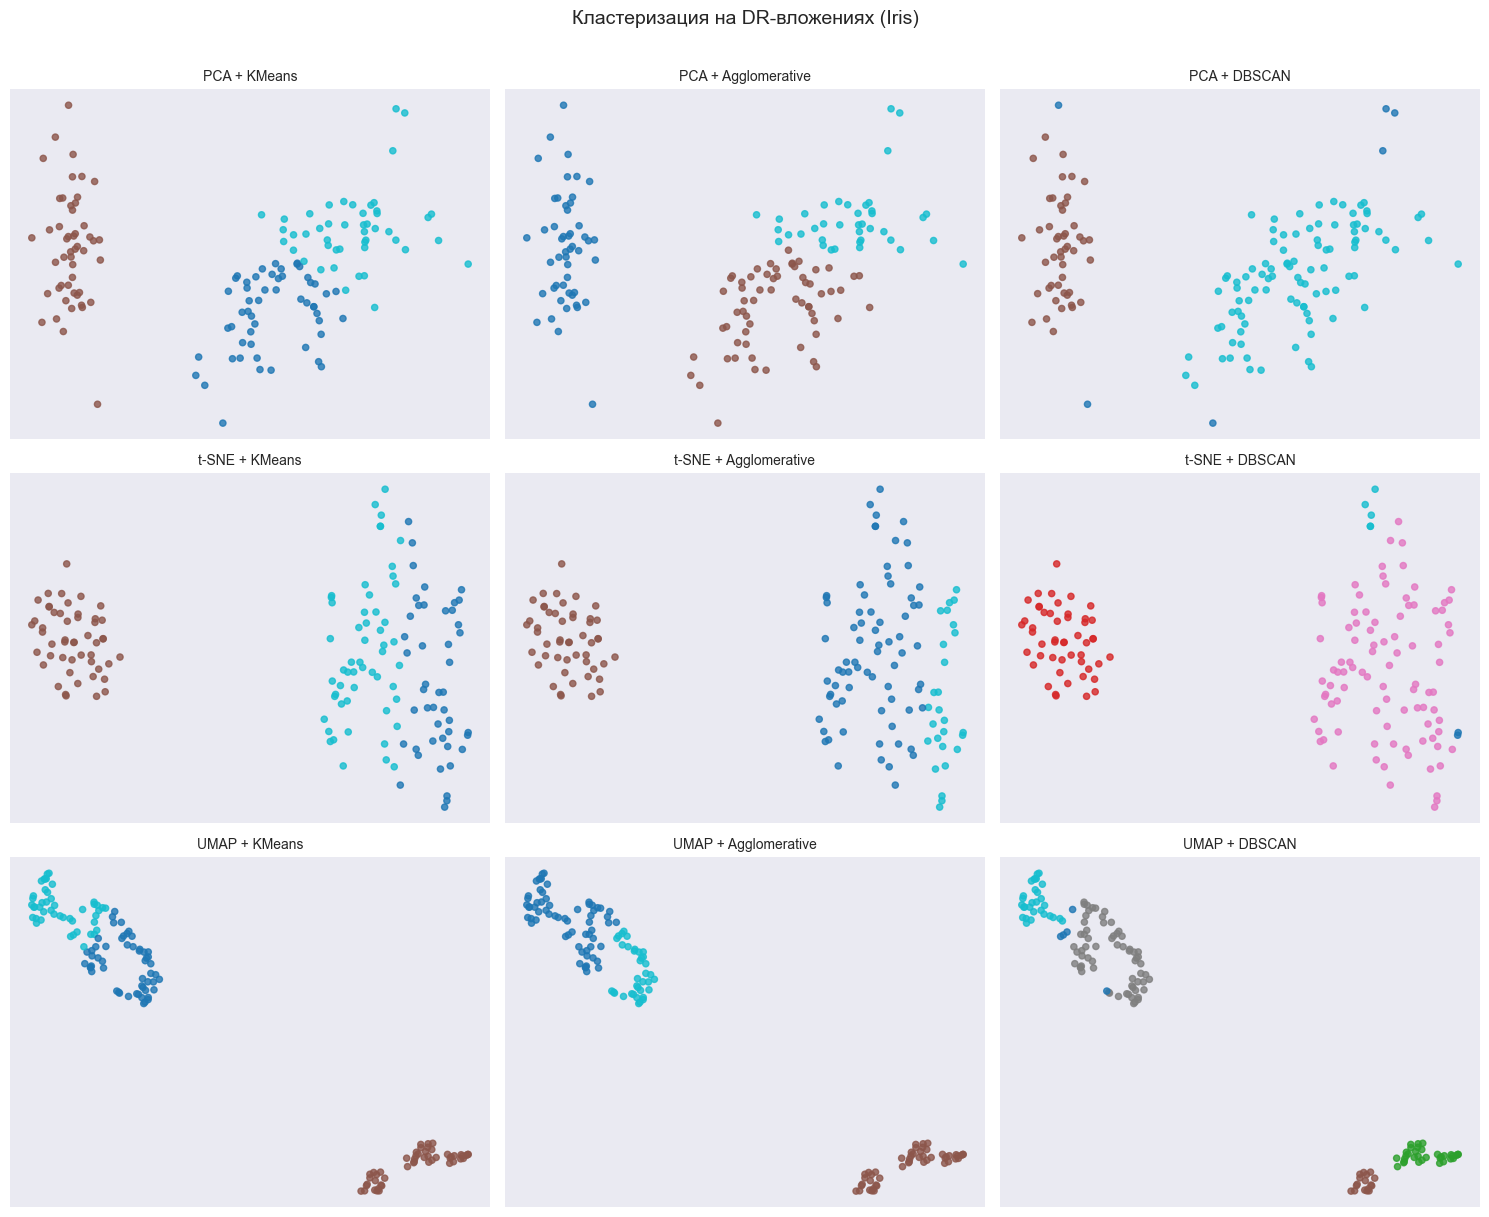

In [8]:
# Визуализация лучшей комбинации на Iris
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for row_i, (dr_name, X_2d) in enumerate(dr_iris.items()):
    labels_dict = all_labels_iris[dr_name]
    for col_j, algo_name in enumerate(['KMeans', 'Agglomerative', 'DBSCAN']):
        ax = axes[row_i][col_j]
        labels = labels_dict[algo_name]
        scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='tab10', s=20, alpha=0.8)
        ax.set_title(f'{dr_name} + {algo_name}', fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle('Кластеризация на DR-вложениях (Iris)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

сетка 3x3 показывает все комбинации DR+кластеризация на Iris. Лучшие визуальные результаты обычно у UMAP+KMeans и t-SNE+KMeans кластеры компактны и разделены

## 5. Результаты на Jobs

In [18]:
N_CLUSTERS = 2
all_scores_jobs = []
all_labels_jobs = {}

for dr_name, X_2d in dr_job.items():
    scores_df, labels_dict = cluster_and_score(X_2d, y, N_CLUSTERS)
    scores_df.insert(0, 'DR', dr_name)
    all_scores_jobs.append(scores_df)
    all_labels_jobs[dr_name] = labels_dict

results_jobs = pd.concat(all_scores_jobs, ignore_index=True)
print('=== Метрики кластеризации на Jobs ===')
print(results_jobs.to_string(index=False))

=== Метрики кластеризации на Jobs ===
   DR      Алгоритм  Кластеров  Silhouette    CH    DB    ARI    AMI
  PCA        KMeans          2       0.437 234.9 0.982 -0.002 -0.002
  PCA Agglomerative          2       0.441 222.7 0.946 -0.002 -0.002
  PCA        DBSCAN          3       0.357 158.8 0.698 -0.000  0.036
t-SNE        KMeans          2       0.348 182.7 1.163  0.089  0.066
t-SNE Agglomerative          2       0.332 152.4 1.231  0.007  0.005
t-SNE        DBSCAN          3       0.196  19.2 0.633  0.004  0.024
 UMAP        KMeans          2       0.433 253.0 0.948  0.010  0.008
 UMAP Agglomerative          2       0.434 221.7 0.798 -0.003 -0.003
 UMAP        DBSCAN         13       0.357 193.0 0.558  0.061  0.091


на Jobs Status 2 класса при ~15 признаках

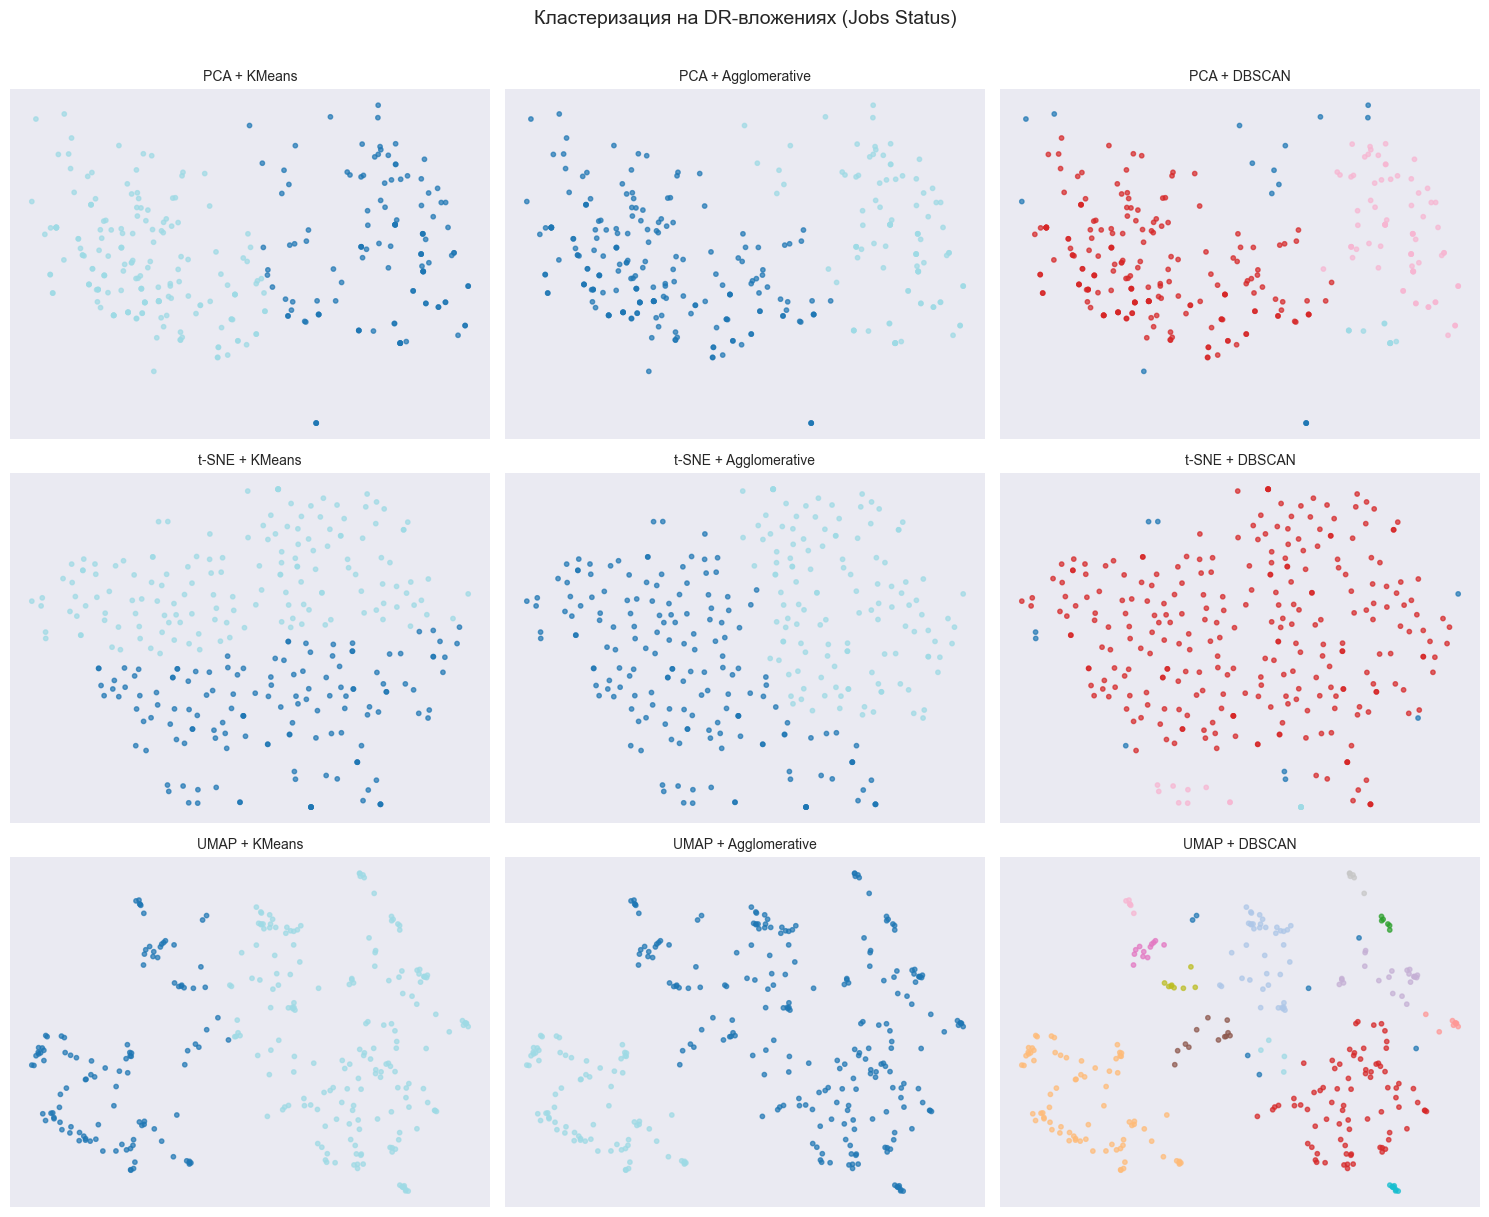

In [19]:
# Визуализация Jobs (лучший DR по ARI для каждого алгоритма)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for row_i, (dr_name, X_2d) in enumerate(dr_job.items()):
    labels_dict = all_labels_jobs[dr_name]
    for col_j, algo_name in enumerate(['KMeans', 'Agglomerative', 'DBSCAN']):
        ax = axes[row_i][col_j]
        labels = labels_dict[algo_name]
        ax.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='tab20', s=10, alpha=0.7)
        ax.set_title(f'{dr_name} + {algo_name}', fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle('Кластеризация на DR-вложениях (Jobs Status)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

на Jobs Status тоже хорошо удается разбить на классы. DBSCAN находит слишком много классов, а у нас их всего 2

## 6. Итоговое сравнение

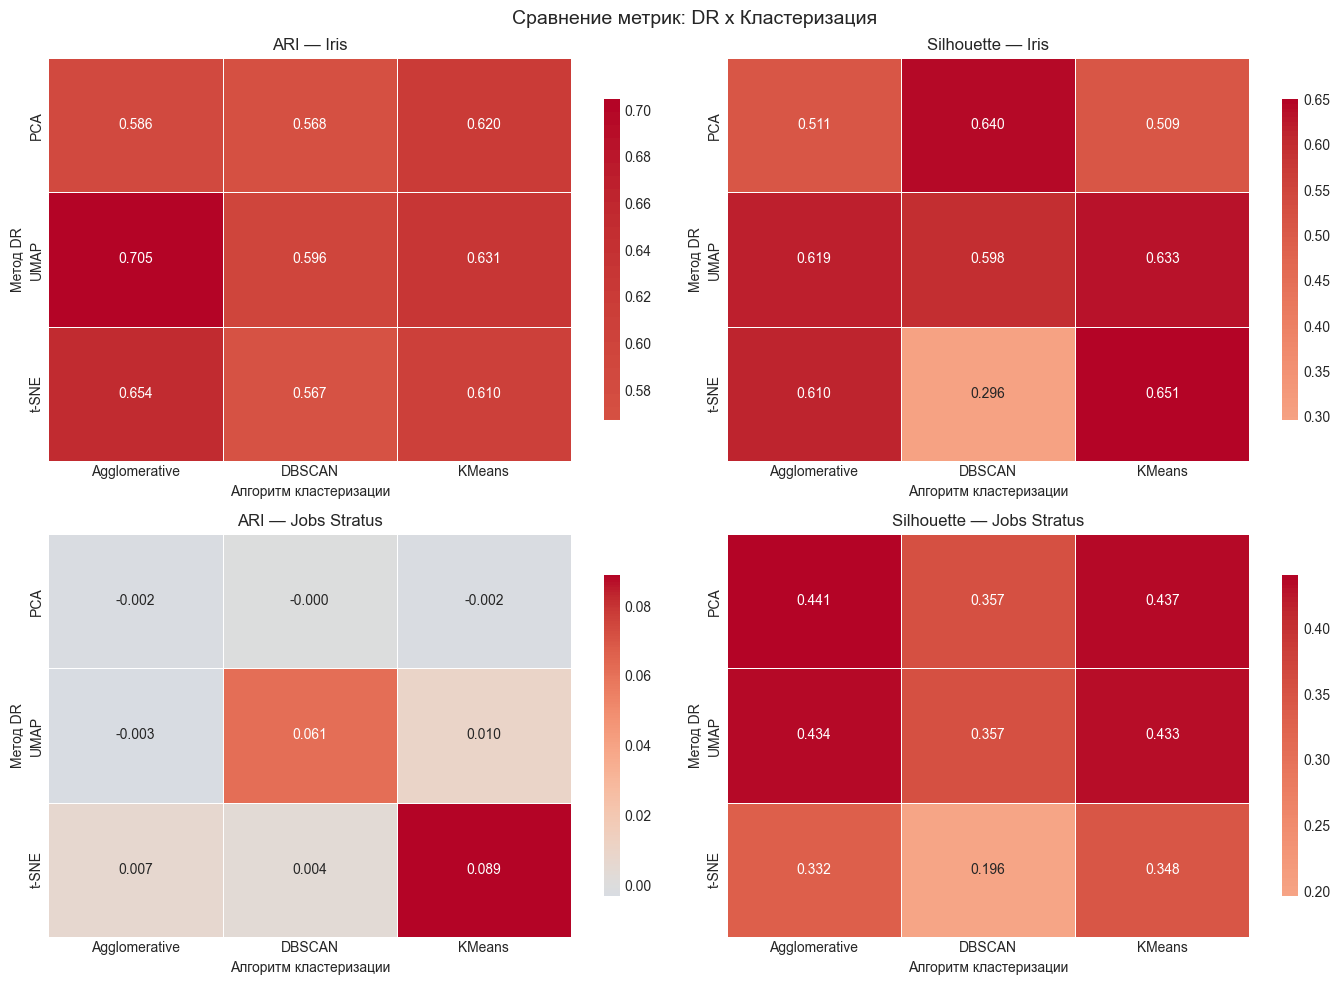

In [21]:
# Heatmap ARI и Silhouette для обоих датасетов
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

datasets_info = [
    (results_iris, 'Iris'),
    (results_jobs, 'Jobs Stratus'),
]
metrics = ['ARI', 'Silhouette']

for col_j, metric in enumerate(metrics):
    for row_i, (df, ds_name) in enumerate(datasets_info):
        ax = axes[row_i][col_j]
        pivot = df.pivot(index='DR', columns='Алгоритм', values=metric)
        sns.heatmap(
            pivot, ax=ax, annot=True, fmt='.3f',
            cmap='coolwarm', center=0, linewidths=0.5,
            cbar_kws={'shrink': 0.8}
        )
        ax.set_title(f'{metric} — {ds_name}', fontsize=12)
        ax.set_xlabel('Алгоритм кластеризации')
        ax.set_ylabel('Метод DR')

plt.suptitle('Сравнение метрик: DR x Кластеризация', fontsize=14)
plt.tight_layout()
plt.show()

 тепловая карта показывает ARI и Silhouette для каждой комбинации DR+алгоритм. Красный цвет эт лучшие значения, белый - худшие

In [ ]:
# Лучшие комбинации по ARI
print('=== Топ-3 комбинации по ARI (Iris) ===')
top_iris = results_iris.dropna(subset=['ARI']).sort_values('ARI', ascending=False).head(3)
print(top_iris[['DR', 'Алгоритм', 'Кластеров', 'Silhouette', 'ARI', 'AMI']].to_string(index=False))

print('\n=== Топ-3 комбинации по ARI (Jobs Status) ===')
top_jobs = results_jobs.dropna(subset=['ARI']).sort_values('ARI', ascending=False).head(3)
print(top_jobs[['DR', 'Алгоритм', 'Кластеров', 'Silhouette', 'ARI', 'AMI']].to_string(index=False))

=== Топ-3 комбинации по ARI (Iris) ===
   DR      Алгоритм  Кластеров  Silhouette   ARI   AMI
 UMAP Agglomerative          3       0.619 0.705 0.740
t-SNE Agglomerative          3       0.610 0.654 0.746
 UMAP        KMeans          3       0.633 0.631 0.663

=== Топ-3 комбинации по ARI (Jobs Status) ===
   DR Алгоритм  Кластеров  Silhouette   ARI   AMI
t-SNE   KMeans          2       0.348 0.089 0.066
 UMAP   DBSCAN         13       0.357 0.061 0.091
 UMAP   KMeans          2       0.433 0.010 0.008


таблица комбинаций сразу показывает лучший выбор. ARI близкий к 1 говорит о совпадении кластеров с истинными метками. AMI близкий к 1 подтверждает результат

из метрик видно, что для целевые классы хорошо описываются кластерами для Iris и плохо для Jobs Status 